## What is an AI:

It refers to computer systems that can perform tasks that normally require human intelligence, such as:

- Understanding and generating language
- Recognizing images, speech, and patterns
- Learning from data
- Solving problems
- Making predictions or recommendations

**For example:**

- Voice assistants like Siri or Google Assistant use AI to understand what you say.
- Recommendation systems on Netflix or YouTube use AI to suggest content you might like.
- Chatbots like ChatGPT use AI to have conversations and answer questions.

**Types of AI**
- Narrow AI – Designed for specific tasks (most AI today, including ChatGPT).
- General AI – A hypothetical AI that could perform any intellectual task a human can do.- 
- Superintelligent AI – A theoretical AI that would surpass human intelligence in many areas.

### Roadmap of AI

Python
   ↓
Maths
   ↓
Data Analysis
   ↓
Machine Learning
   ↓
Deep Learning
   ↓
NLP
   ↓
Generative AI
   ↓
LangChain / RAG   
   ↓
AI Agents
   ↓
MLOps & Deployment

## Langchain

- LangChain is a framework that helps you build applications using Large Language Models (LLMs) more easily and in a structured way.

- It does NOT create AI models. Instead, it helps you connect, organize, and control LLMs in real applications.

#### Purpose of langchain

- LLMs alone (like GPT) can:

    - answer questions
    - generate text

- But they don’t easily connect to real systems like:

    - databases
    - APIs
    - files (PDF, Excel)
    - external tools

#### Without Langchain

Suppose you want to build an AI assistant that:

- Receives a user question.
- Searches a PDF.
- Searches a database.
- Calls a weather API.
- Sends all information to an LLM.
- Returns the final answer.

Without LangChain, you have to manually write and connect all these pieces:

## RAG

RAG = Retrieval-Augmented Generation

- Retrieval → Find relevant information.
- Augmented → Add that information to the prompt.
- Generation → Let the LLM generate the answer.

### why do we need RAG

- An LLM only knows what it learned during training.

    - For example, ask:

        "What is the leave policy in my company?"

- The LLM doesn't know your company's private documents.

Without RAG:

    User Question
        ↓
       LLM
        ↓
    "I don't know"

or it may hallucinate (make up an answer).

With RAG
    User Question
        ↓
    Search Company Documents
        ↓
    Retrieve Relevant Content
        ↓
    Send Content + Question to LLM
        ↓
    Generate Answer

Now the LLM answers based on your documents.

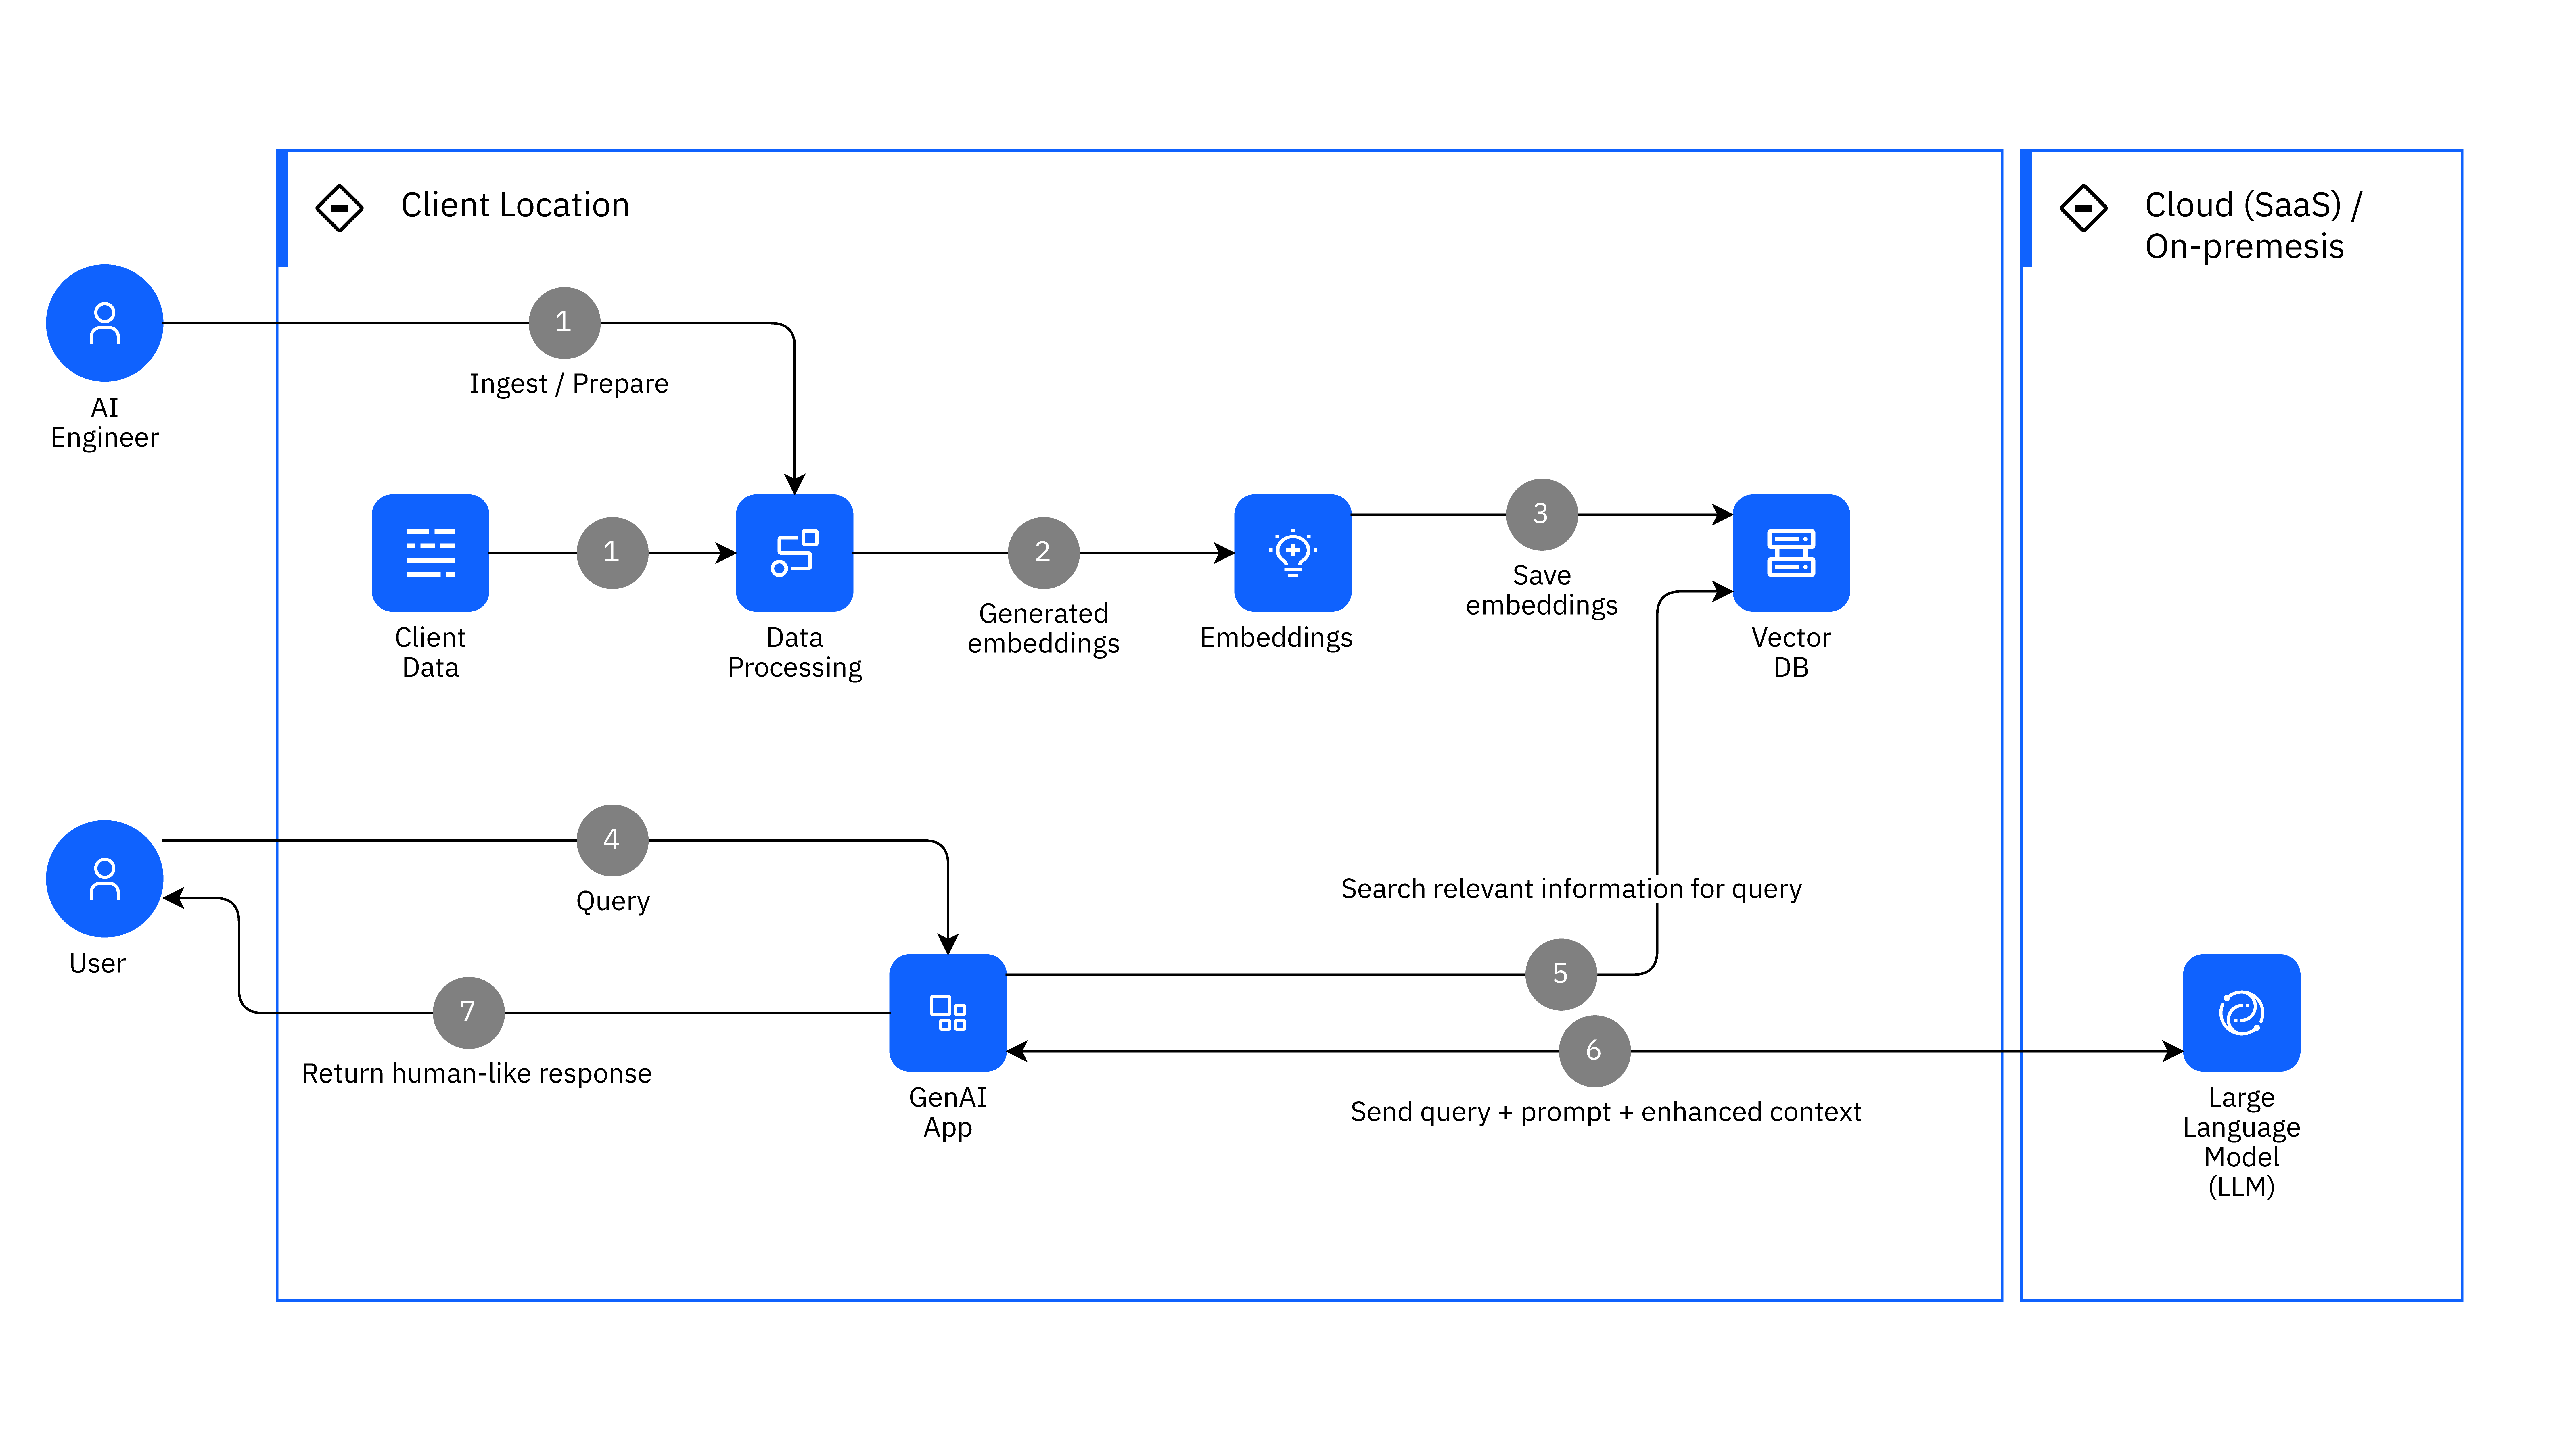

### What RAG Actually Processes

- RAG primarily works on text.

- Even when you provide:

    - PDF
    - Word document
    - Website
    - Database

- the content is usually converted into text chunks before indexing.

### Embeddings

- An embedding is a numerical representation (vector) of data that captures its meaning.
- Embeddings convert text, images, or other data into numbers that computers can compare and search.

### Why do we need Embeddings


- Computers don't understand text like humans do.
- For example:

    Python is a programming language

    For us, this sentence has meaning.

    For a computer, it's just characters.

    So we convert it into numbers:

    [0.12, 0.45, -0.78, 0.33, ...]

- This list of numbers is called an embedding vector.

Example:

- Consider these sentences:

    1. Python is a programming language.
    2. Python is used for software development.
    3. I like eating pizza.

- After creating embeddings:

    Sentence 1 → [0.1, 0.3, 0.5, ...]
    Sentence 2 → [0.2, 0.4, 0.6, ...]
    Sentence 3 → [0.9, 0.1, 0.2, ...]

Sentences 1 and 2 have similar meanings, so their embeddings will be close together.

Sentence 3 is about food, so its embedding will be farther away.

### Types of embeddings

Embedding Models
│
├── Text Embedding
├── Image Embedding
├── Audio Embedding
├── Video Embedding
├── Code Embedding
└── Multimodal Embedding

For most AI/RAG projects, you'll primarily encounter:

Text Embeddings (most common)
Image Embeddings
Multimodal Embeddings

The others are more specialized for audio, video, and code-focused applications.


## Chunking:


- Chunking means breaking a large document into smaller pieces (chunks) before creating embeddings.

### Why do we need Chunking

Suppose you have a PDF with 100 pages.

Employee Handbook
- Leave Policy
- Salary Policy
- Travel Policy
- Insurance Policy
...

If you create one embedding for the entire document, the embedding will represent all topics mixed together.

Then when a user asks:

How many sick leaves are allowed?

the system may struggle to find the exact information

Instead, We Split the Document
Chunk 1:
Leave Policy

Chunk 2:
Salary Policy

Chunk 3:
Travel Policy

Chunk 4:
Insurance Policy

Now each chunk gets its own embedding.

Chunk 1 → Embedding 1
Chunk 2 → Embedding 2
Chunk 3 → Embedding 3
Chunk 4 → Embedding 4

This makes retrieval much more accurate.

### chunk size

- Chunk size is the amount of text placed into a single chunk before creating an embedding.

### chunk overlap


Many RAG systems use overlap.

- Without overlap:

    - Chunk 1:
        - Python is a programming language.

    - Chunk 2:
        - It is widely used in AI.

    - The relationship between the sentences may be lost.

- With overlap:

    - Chunk 1:
        - Python is a programming language.

    - Chunk 2:
        - Python is a programming language.
        - It is widely used in AI.

Some text appears in both chunks.

## What is vector database

- A vector database is a special database designed to store and search embeddings (vectors) efficiently.
- We use a vector database because embeddings are vectors, and we need a fast way to find the most similar vectors.

#### Why a Normal SQL Database Is Not Enough

SQL databases are optimized for exact matches:

    SELECT * FROM employees
    WHERE employee_id = 101;

or

    SELECT * FROM employees
    WHERE name = 'John';

But RAG needs semantic search:

    Question:
    "How many medical leaves are allowed?"

    Document:

    "Sick Leave: 10 days"

    The words are different:

    medical leave ≠ sick leave

    Yet the meanings are similar.

    A vector database can find this relationship because it compares embeddings, not exact words.

#### What the Vector Database Actually Does


Stores Embeddings
    Vector
       +
    Original Chunk
       +
    Metadata

Example:

    Vector: [0.12, 0.45, 0.78]
    Text: "Sick Leave: 10 days"
    Source: employee_handbook.pdf

Performs Similarity Search
    Query Vector
        ↓
    Find Closest Vectors
        ↓
    Return Top 5 Matches

##### Mostly use vector database

- FAISS
- ChromaDB
- Weaviate
- Pinecone
- Qdrant
- Milvus

In [ ]:
pip install easyocr opencv-python faiss-cpu sentence-transformers langchain langchain-community langchain-text-splitters langchain-huggingface langchain-ollama

In [ ]:
pip install langchain-chroma

In [ ]:
import easyocr

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
# from langchain_community.vectorstores import FAISS
# from langchain_community.vectorstores import Chroma
from langchain_chroma import Chroma
from langchain_ollama import ChatOllama


image_path = "image_dataset.png"

reader = easyocr.Reader(['en'])

result = reader.readtext(image_path)

text = "\n".join(
    item[1]
    for item in result
)

print("\n===== EXTRACTED TEXT =====\n")
# print(text)

if not text.strip():
    raise ValueError(
        "No text found in the image."
    )

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

chunks = splitter.split_text(text)

print(f"\nTotal Chunks Created: {len(chunks)}")


embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


vector_db = Chroma.from_texts(
    texts=chunks,
    embedding=embeddings
)

print("\nChroma index created successfully.")

question = input(
    "\nEnter your question: "
)

docs = vector_db.similarity_search(
    question,
    k=3
)

print("\n===== RETRIEVED CHUNKS =====")

for i, doc in enumerate(docs, start=1):
    print(f"\nChunk {i}")
    print("-" * 50)
    print(doc.page_content)


if not docs:
    raise ValueError(
        "No relevant chunks found."
    )


context = "\n".join(
    doc.page_content
    for doc in docs
)

print("\n===== CONTEXT SENT TO LLM =====\n")
# print(context)

llm = ChatOllama(
    model="llama3"
)

prompt = f"""
You are a helpful assistant.

Answer ONLY from the provided context.

If the answer is not available in the context,
reply with:

"I could not find the answer in the provided context."

Context:
{context}

Question:
{question}
"""


response = llm.invoke(prompt)

print("\n===== FINAL ANSWER =====\n")
print(f"The llm response is: {response.content}")